In [1]:
# Standard library
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
from matplotlib.colors import to_rgba
from scipy.stats import gaussian_kde

# Project-local setup
sys.path.append("../src")
from plot_style import set_project_style, COLOR_DARK, COLOR_ACCENT, COLOR_BG, COLOR_BLUE, COLOR_GRAY

set_project_style()
data_dir = Path("../data/processed")
figures_dir = Path("../docs/report_figures")
assets_dir = Path("../assets/figures")
assets_dir.mkdir(parents=True, exist_ok=True)

In [3]:
patient_features = pd.read_parquet(data_dir / "patient_features.parquet")
patient_features.describe()

,BMI,Creatinine,Glucose,HDL,HbA1c,LDL,Total Cholesterol,Triglycerides,creatinine_measured,BIRTHDATE,DEATHDATE,AGE,CCI,on_metformin,on_insulin,on_other_antidiabetic,encounters_per_year
count,1763.000000,1763.000000,1763.000000,1763.000000,1763.00000,1763.00000,1763.000000,1763.000000,1763.000000,1763,418,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000
mean,28.765797,1.514067,102.237209,49.458140,5.57907,121.50363,201.380318,163.651617,0.476461,1957-08-09 16:04:37.708452,2010-09-18 16:59:42.775119,64.627907,2.311968,0.504821,0.373227,0.009643,2.422133
min,18.700000,0.400000,64.000000,10.700000,2.30000,9.50000,93.800000,100.000000,0.000000,1915-08-16 00:00:00,1966-12-07 00:00:00,19.000000,1.000000,0.000000,0.000000,0.000000,0.430180
25%,27.700000,0.900000,84.800000,44.000000,4.00000,101.30000,173.600000,127.550000,0.000000,1947-03-28 12:00:00,2003-03-04 18:00:00,55.000000,1.000000,0.000000,0.000000,0.000000,0.935608
50%,28.100000,0.900000,103.300000,51.200000,6.00000,125.60000,207.500000,156.000000,0.000000,1960-01-29 00:00:00,2015-03-13 12:00:00,63.000000,2.000000,1.000000,0.000000,0.000000,1.310079
75%,30.000000,2.100000,115.800000,56.300000,6.90000,141.35000,225.700000,179.900000,1.000000,1969-12-04 00:00:00,2020-12-28 06:00:00,74.000000,3.000000,1.000000,1.000000,0.000000,2.484712
max,48.100000,4.900000,199.800000,79.900000,12.00000,264.40000,315.500000,529.100000,1.000000,2006-08-25 00:00:00,2026-05-27 00:00:00,110.000000,10.000000,1.000000,1.000000,1.000000,20.643369
std,2.307802,0.765321,23.675387,10.457415,1.51620,34.79117,37.430288,61.368593,0.499587,NaN,NaN,14.963480,1.445259,0.500119,0.483799,0.097750,2.715935


In [4]:
patient_features_clustered = pd.read_parquet(data_dir / "patient_features_clustered.parquet")
patient_features_clustered.describe()

,BMI,Creatinine,Glucose,HDL,HbA1c,LDL,Triglycerides,creatinine_measured,BIRTHDATE,DEATHDATE,GENDER,AGE,CCI,on_metformin,on_insulin,on_other_antidiabetic,encounters_per_year,encounters_per_year_log,kmeans_k3
count,1763.000000,1763.000000,1763.000000,1763.000000,1763.00000,1763.00000,1763.000000,1763.000000,1763,418,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000
mean,28.765797,1.514067,102.237209,49.458140,5.57907,121.50363,163.651617,0.476461,1957-08-09 16:04:37.708452,2010-09-18 16:59:42.775119,0.521271,64.627907,2.311968,0.504821,0.373227,0.009643,2.422133,1.044447,0.468520
min,18.700000,0.400000,64.000000,10.700000,2.30000,9.50000,100.000000,0.000000,1915-08-16 00:00:00,1966-12-07 00:00:00,0.000000,19.000000,1.000000,0.000000,0.000000,0.000000,0.430180,0.357801,0.000000
25%,27.700000,0.900000,84.800000,44.000000,4.00000,101.30000,127.550000,0.000000,1947-03-28 12:00:00,2003-03-04 18:00:00,0.000000,55.000000,1.000000,0.000000,0.000000,0.000000,0.935608,0.660421,0.000000
50%,28.100000,0.900000,103.300000,51.200000,6.00000,125.60000,156.000000,0.000000,1960-01-29 00:00:00,2015-03-13 12:00:00,1.000000,63.000000,2.000000,1.000000,0.000000,0.000000,1.310079,0.837282,0.000000
75%,30.000000,2.100000,115.800000,56.300000,6.90000,141.35000,179.900000,1.000000,1969-12-04 00:00:00,2020-12-28 06:00:00,1.000000,74.000000,3.000000,1.000000,1.000000,0.000000,2.484712,1.248384,1.000000
max,48.100000,4.900000,199.800000,79.900000,12.00000,264.40000,529.100000,1.000000,2006-08-25 00:00:00,2026-05-27 00:00:00,1.000000,110.000000,10.000000,1.000000,1.000000,1.000000,20.643369,3.074699,2.000000
std,2.307802,0.765321,23.675387,10.457415,1.51620,34.79117,61.368593,0.499587,NaN,NaN,0.499689,14.963480,1.445259,0.500119,0.483799,0.097750,2.715935,0.542490,0.815222


In [5]:
# Shared across all figures
cluster_label_mapping = {
    "Mild":         "Mild, lower treatment intensity",
    "Multimorbid":  "Multimorbid, high care complexity",
    "Dyslipidemic": "Dyslipidemic / metabolic",
}
cluster_colors = {
    "Mild":         COLOR_GRAY,
    "Multimorbid":  COLOR_ACCENT,
    "Dyslipidemic": COLOR_BLUE,
}
ordered_clusters = ["Mild", "Multimorbid", "Dyslipidemic"]

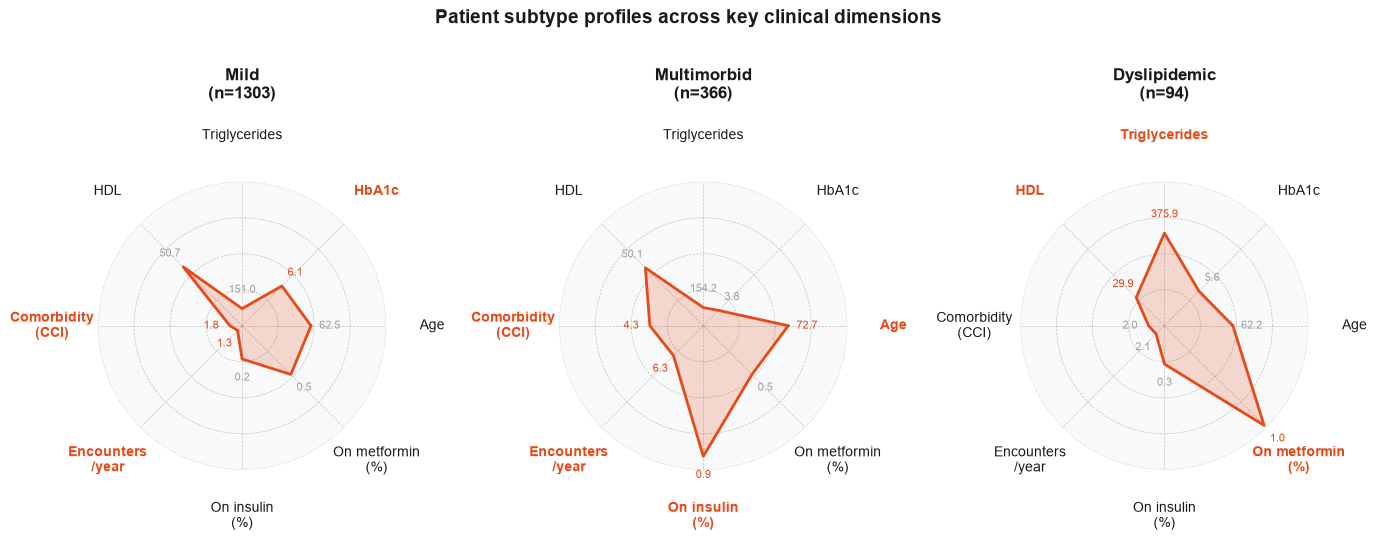

In [6]:
# --- Figure 1: Cluster radar profiles ----------------------------------------
# Normalised on full-dataset min/max so axes are comparable across clusters.
# Source: patient_features_clustered

profile_cols = ["AGE", "HbA1c", "Triglycerides", "HDL", "CCI",
                "encounters_per_year", "on_insulin", "on_metformin"]
axis_labels  = ["Age", "HbA1c", "Triglycerides", "HDL",
                "Comorbidity\n(CCI)", "Encounters\n/year",
                "On insulin\n(%)", "On metformin\n(%)"]

cluster_order = [cluster_label_mapping[k] for k in ordered_clusters]
cluster_short = ordered_clusters

# Clinically discriminating axes per cluster — highlighted in accent colour
highlight = {
    "Mild, lower treatment intensity":   ["HbA1c", "Comorbidity\n(CCI)",
                                          "Encounters\n/year"],
    "Dyslipidemic / metabolic":          ["Triglycerides", "HDL",
                                          "On metformin\n(%)"],
    "Multimorbid, high care complexity": ["Age", "Comorbidity\n(CCI)",
                                          "Encounters\n/year", "On insulin\n(%)"],
}

# Cluster means, normalised on full-dataset range
profile      = patient_features_clustered.groupby("cluster_label")[profile_cols].mean()
col_min      = patient_features_clustered[profile_cols].min()
col_max      = patient_features_clustered[profile_cols].max()
profile_norm = (profile - col_min) / (col_max - col_min)

N      = len(profile_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]    # close the polygon

fig, axes = plt.subplots(1, 3, figsize=(14, 5), subplot_kw=dict(polar=True))
fig.suptitle("Patient subtype profiles across key clinical dimensions",
             fontsize=14, fontweight="bold", color=COLOR_DARK, y=1.05)

for ax, label, short in zip(axes, cluster_order, cluster_short):
    values = profile_norm.loc[label].tolist()
    values += values[:1]    # close the polygon

    ax.set_facecolor(COLOR_BG)
    ax.grid(color=COLOR_GRAY, linewidth=0.5, linestyle="--", alpha=0.6)
    ax.spines["polar"].set_visible(False)

    ax.fill(angles, values, color=COLOR_ACCENT, alpha=0.20)
    ax.plot(angles, values, color=COLOR_ACCENT, linewidth=2)

    # Axis labels: accent + bold if discriminating for this cluster
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])
    for ang, lbl in zip(angles[:-1], axis_labels):
        is_hi = lbl in highlight[label]
        ax.text(ang, 1.32, lbl,
                ha="center", va="center", fontsize=10,
                color=COLOR_ACCENT if is_hi else COLOR_DARK,
                fontweight="bold" if is_hi else "normal")

    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)

    # Raw values annotated just outside the polygon surface
    raw_vals  = profile.loc[label]
    norm_vals = profile_norm.loc[label]
    for ang, lbl, col in zip(angles[:-1], axis_labels, profile_cols):
        r_annot = min(norm_vals[col] + 0.13, 1.13)
        ax.text(ang, r_annot, f"{raw_vals[col]:.1f}",
                ha="center", va="center", fontsize=8,
                color=COLOR_ACCENT if lbl in highlight[label] else COLOR_GRAY)

    n = (patient_features_clustered["cluster_label"] == label).sum()
    ax.set_title(f"{short}\n(n={n})", fontsize=12, fontweight="bold",
                 color=COLOR_DARK, pad=60)

plt.tight_layout()
plt.savefig(figures_dir / "fig1_cluster_radar.png", dpi=150, bbox_inches="tight")
plt.savefig(assets_dir / "fig1_cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()

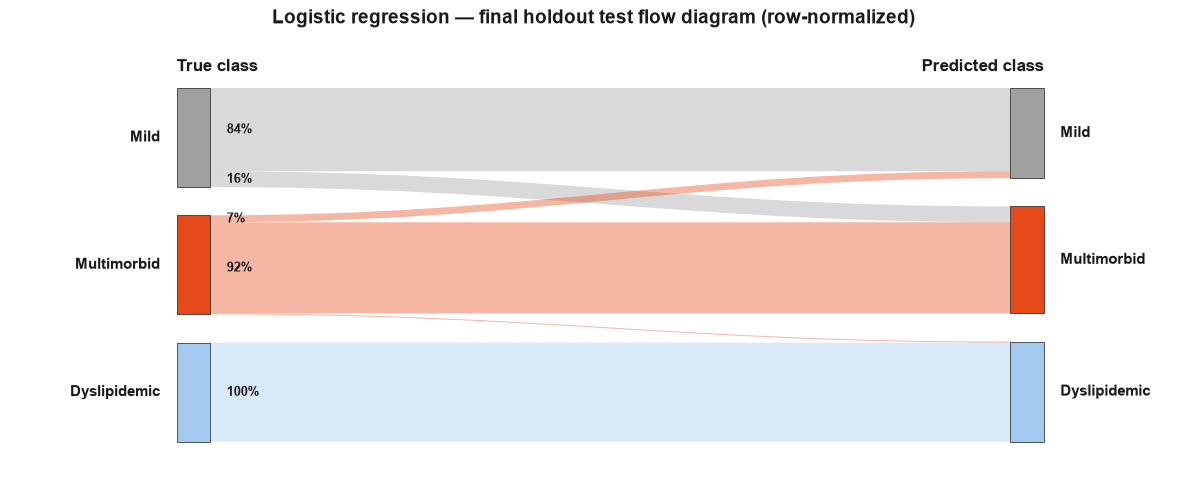

In [7]:
# --- Figure 2: Logistic regression flow diagram (Sankey-style) ---------------
# Row-normalised confusion matrix as flowing streams: true class (left)
# → predicted class (right). Source: logistic regression holdout test (n=353)

cm_test       = np.array([[0.84, 0.16, 0.00],
                           [0.07, 0.92, 0.01],
                           [0.00, 0.00, 1.00]])
n_cls          = len(ordered_clusters)

# Layout constants
NODE_W = 0.04
LEFT_X, RIGHT_X, GAP = 0.0, 1.0, 0.08
base_h = (1.0 - GAP * (n_cls - 1)) / n_cls

# Left nodes: equal height; right nodes: height ∝ incoming flow sum
left_h = [base_h] * n_cls
left_y = [i * (base_h + GAP) for i in range(n_cls)][::-1]
right_h = [s * base_h for s in cm_test.sum(axis=0)]
right_y = []
y = 0.0
for h in right_h[::-1]:
    right_y.append(y); y += h + GAP
right_y = right_y[::-1]

# Cursors: track the top of the next available slot on each node
l_cur = {i: left_y[i]  + left_h[i]  for i in range(n_cls)}
r_cur = {j: right_y[j] + right_h[j] for j in range(n_cls)}

def _flow_patch(xl, yl_b, yl_t, xr, yr_b, yr_t, color):
    """Cubic Bezier S-curve connecting two vertical segments."""
    cp = 0.4
    verts = [(xl, yl_b), (xl+cp, yl_b), (xr-cp, yr_b), (xr, yr_b),
             (xr, yr_t), (xr-cp, yr_t), (xl+cp, yl_t), (xl, yl_t), (xl, yl_b)]
    codes = [patches.Path.MOVETO,
             patches.Path.CURVE4, patches.Path.CURVE4, patches.Path.CURVE4,
             patches.Path.LINETO,
             patches.Path.CURVE4, patches.Path.CURVE4, patches.Path.CURVE4,
             patches.Path.CLOSEPOLY]
    return patches.PathPatch(patches.Path(verts, codes),
                             facecolor=to_rgba(color, 0.4), edgecolor="none", zorder=1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.1, 1.1)

# Draw flows
for i, true_lbl in enumerate(ordered_clusters):
    for j in range(n_cls):
        frac = cm_test[i, j]
        if frac <= 0.005:
            continue
        fh = frac * base_h
        yl_t, yl_b = l_cur[i], l_cur[i] - fh
        yr_t, yr_b = r_cur[j], r_cur[j] - fh
        l_cur[i], r_cur[j] = yl_b, yr_b

        ax.add_patch(_flow_patch(LEFT_X + NODE_W, yl_b, yl_t,
                                 RIGHT_X, yr_b, yr_t,
                                 cluster_colors[true_lbl]))
        if frac > 0.05:    # annotate only flows large enough to read
            ax.text(LEFT_X + NODE_W + 0.02, yl_t - fh / 2,
                    f"{frac*100:.0f}%", va="center", ha="left",
                    fontsize=9, color=COLOR_DARK, weight="bold")

# Draw nodes + labels (left and right share the same structure)
for i, lbl in enumerate(ordered_clusters):
    col = cluster_colors[lbl]
    for x, y, h, ha, x_lbl in [
        (LEFT_X,  left_y[i],  left_h[i],  "right", LEFT_X - 0.02),
        (RIGHT_X, right_y[i], right_h[i], "left",  RIGHT_X + NODE_W + 0.02),
    ]:
        ax.add_patch(patches.Rectangle((x, y), NODE_W, h,
                                       facecolor=col, edgecolor=COLOR_DARK,
                                       linewidth=0.5, zorder=2))
        ax.text(x_lbl, y + h / 2, lbl,
                ha=ha, va="center", weight="bold", color=COLOR_DARK)

# Headers and title
ax.text(LEFT_X,           1.06, "True class",      ha="left",  va="center",
        weight="bold", fontsize=12, color=COLOR_DARK)
ax.text(RIGHT_X + NODE_W, 1.06, "Predicted class", ha="right", va="center",
        weight="bold", fontsize=12, color=COLOR_DARK)
ax.set_title("Logistic regression — final holdout test flow diagram (row-normalized)",
             pad=15, fontsize=14, weight="bold", y=1.02)
ax.axis("off")

plt.tight_layout()
plt.savefig(figures_dir / "fig2_logistic_flow_diagram.png", dpi=150, bbox_inches="tight")
plt.savefig(assets_dir / "fig2_logistic_flow_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

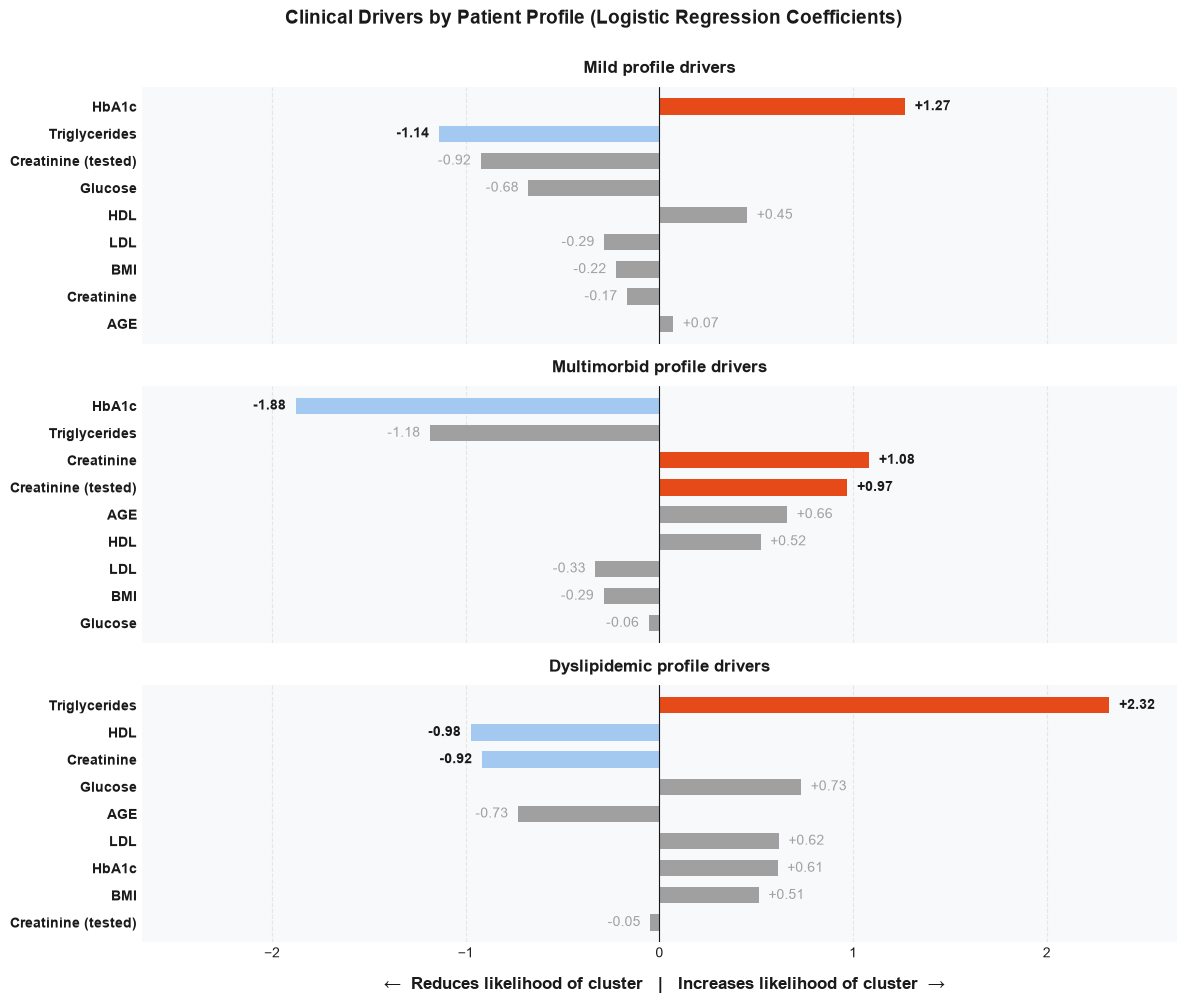

In [8]:
# --- Figure 3: Clinical drivers per cluster (LR coefficients) ----------------
# Horizontal bar charts of logistic regression coefficients, one panel per
# cluster. Dominant drivers highlighted; all others in neutral grey.
# Source: coefficients exported from notebook 04

coefs = pd.read_csv(data_dir / "coefs.csv", index_col=0)

dominant_drivers = {
    "Mild":         ["HbA1c", "Triglycerides"],
    "Multimorbid":  ["HbA1c", "Creatinine", "creatinine_measured"],
    "Dyslipidemic": ["Triglycerides", "HDL", "Creatinine"],
}
clean_names = {"creatinine_measured": "Creatinine (tested)"}
max_val          = np.abs(coefs.values).max() * 1.15

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, cluster in zip(axes, ordered_clusters):
    s       = coefs.loc[cluster].sort_values(key=np.abs, ascending=True)
    ylabels = [clean_names.get(f, f) for f in s.index]
    colors  = [
        (COLOR_ACCENT if v >= 0 else COLOR_BLUE) if f in dominant_drivers[cluster]
        else COLOR_GRAY
        for f, v in s.items()
    ]

    bars = ax.barh(ylabels, s.values, color=colors, edgecolor="none", height=0.6)

    ax.axvline(0, color=COLOR_DARK, linewidth=0.8, zorder=2)
    ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=1)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(f"{cluster} profile drivers", fontsize=12,
                 weight="bold", pad=10, color=COLOR_DARK)
    ax.tick_params(axis="both", length=0, labelsize=10)
    plt.setp(ax.get_yticklabels(), weight="bold", color=COLOR_DARK)
    ax.set_xlim(-max_val, max_val)

    # Value labels at bar tips; dominant drivers in dark, others in grey
    for bar, feat, val in zip(bars, s.index, s.values):
        is_dom = feat in dominant_drivers[cluster]
        ax.text(val + (0.05 if val >= 0 else -0.05),
                bar.get_y() + bar.get_height() / 2,
                f"{val:+.2f}", va="center",
                ha="left" if val >= 0 else "right",
                fontsize=10,
                color=COLOR_DARK if is_dom else COLOR_GRAY,
                weight="bold"   if is_dom else "normal")

axes[-1].set_xlabel(
    "  ←  Reduces likelihood of cluster   |   Increases likelihood of cluster  →",
    fontsize=12, labelpad=12, weight="bold", color=COLOR_DARK)

plt.suptitle("Clinical Drivers by Patient Profile (Logistic Regression Coefficients)",
             fontsize=14, weight="bold", y=1.0)
plt.tight_layout()
plt.savefig(figures_dir / "fig3_bar_clinical_drivers.png", dpi=150, bbox_inches="tight")
plt.show()

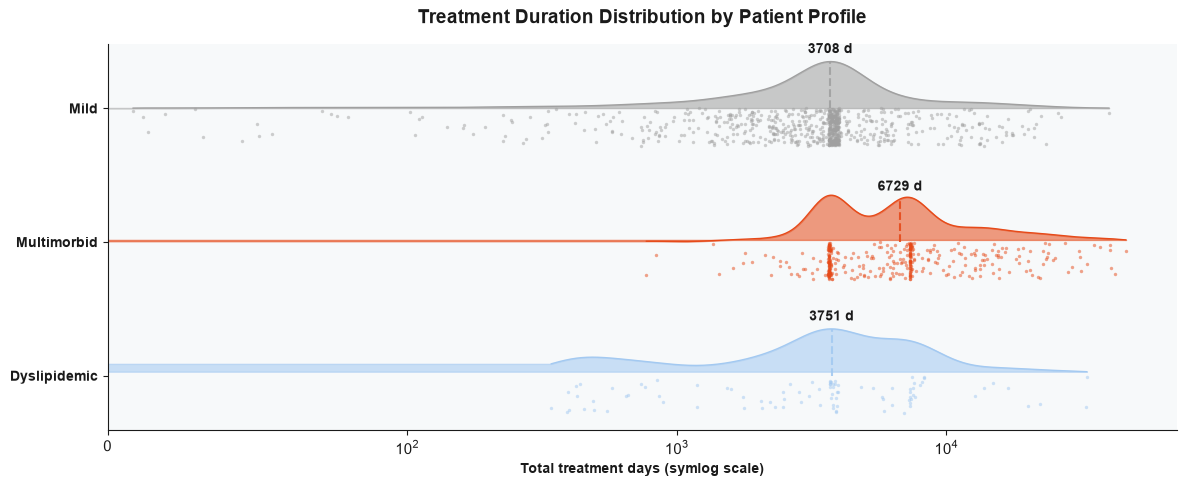

In [9]:
# --- Figure 4: Treatment duration distribution — raincloud plot ---------------
# Pharmacologically managed patients only (diet/lifestyle patients excluded).
# KDE computed on log-transformed values, back-projected to original scale.
# Symlog x-axis to handle zero-heavy distribution without losing detail.
# Source: df_pharma exported from notebook 05.

df_pharma = pd.read_csv(data_dir / "df_pharma.csv")

# Stack order: bottom → top (Dyslipidemic, Multimorbid, Mild)
plot_order = ordered_clusters[::-1]

fig, ax = plt.subplots(figsize=(12, 5))

for i, short_label in enumerate(plot_order):
    raw_label = cluster_label_mapping[short_label]
    color     = cluster_colors[short_label]
    vals      = df_pharma.loc[df_pharma["cluster_label"] == raw_label,
                               "treatment_days_total"].values

    # KDE on log-scale for smoothness, back-projected to original scale
    log_vals    = np.log1p(vals)
    kde         = gaussian_kde(log_vals, bw_method=0.25)
    x_log       = np.linspace(log_vals.min(), log_vals.max(), 300)
    y_kde_norm  = kde(x_log) / kde(x_log).max() * 0.35   # cap at 0.35 (half spacing)
    x_raw       = np.expm1(x_log)

    # Half-violin (KDE surface above baseline)
    ax.fill_betweenx(i + y_kde_norm, x_raw, alpha=0.55, color=color)
    ax.plot(x_raw, i + y_kde_norm, color=color, linewidth=1)

    # Strip plot (jittered points below baseline)
    jitter = np.random.default_rng(42).uniform(-0.28, 0.0, size=len(vals))
    ax.scatter(vals, i + jitter, color=color, alpha=0.5, s=6,
               linewidths=0, zorder=2)

    # Median: dashed line from baseline to KDE surface + annotation
    median_val       = np.median(vals)
    kde_at_median    = kde(np.array([np.log1p(median_val)]))[0]
    kde_at_median_norm = kde_at_median / kde(x_log).max() * 0.35
    ax.plot([median_val, median_val], [i, i + kde_at_median_norm],
            color=color, linewidth=1.5, linestyle="--", zorder=4, alpha=0.9)
    ax.annotate(f"{median_val:.0f} d",
                xy=(median_val, i + kde_at_median_norm),
                xytext=(0, 4), textcoords="offset points",
                fontsize=10, color=COLOR_DARK,
                ha="center", va="bottom", fontweight="bold")

ax.set_xscale("symlog", linthresh=100)
ax.set_xlim(left=0)
ax.set_xlabel("Total treatment days (symlog scale)", fontsize=10, weight="bold")
ax.set_yticks(range(len(plot_order)))
ax.set_yticklabels(plot_order, fontsize=10, weight="bold")
ax.set_title("Treatment Duration Distribution by Patient Profile",
             fontsize=14, weight="bold", pad=15)

plt.tight_layout()
plt.savefig(figures_dir / "fig4_raincloud_treatment_intensity.png",
            dpi=150, bbox_inches="tight")
plt.savefig(assets_dir / "fig4_raincloud_treatment_intensity.png",
            dpi=150, bbox_inches="tight")            
plt.show()

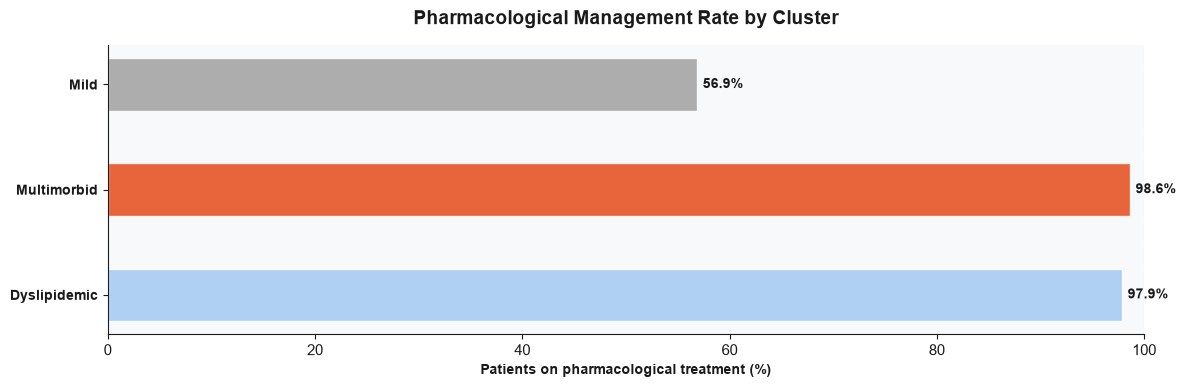

In [58]:
# --- Figure 5: Pharmacological management rate by cluster ---------------------
# Percentage of patients on ≥1 antidiabetic medication per cluster.
# Derived from treatment_days_total > 0 (all patients, including diet-only).
# Source: df_scores exported from notebook 05.

df_scores = pd.read_csv(data_dir / "df_scores.csv")

# Compute pharmacological rate per cluster
pharma_pct = (
    df_scores.assign(pharmacological=df_scores["treatment_days_total"] > 0)
    .groupby("cluster_label")["pharmacological"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"pharmacological": "pct_pharma"})
)

# Bottom-to-top stack order (mirrors fig4)
plot_order = ordered_clusters[::-1]

fig, ax = plt.subplots(figsize=(12, 4))

for i, short_label in enumerate(plot_order):
    raw_label = cluster_label_mapping[short_label]
    pct       = pharma_pct.loc[pharma_pct["cluster_label"] == raw_label,
                                "pct_pharma"].values[0]
    ax.barh(i, pct, color=cluster_colors[short_label], alpha=0.85, height=0.5)
    ax.annotate(f"{pct:.1f}%",
                xy=(pct, i), xytext=(4, 0), textcoords="offset points",
                fontsize=10, color=COLOR_DARK, va="center",
                fontweight="bold", clip_on=False)

ax.set_xlim(0, 100)
ax.set_yticks(range(len(plot_order)))
ax.set_yticklabels(plot_order, fontsize=10, fontweight="bold")
ax.set_xlabel("Patients on pharmacological treatment (%)",
              fontsize=10, weight="bold")
ax.set_title("Pharmacological Management Rate by Cluster",
             fontsize=14, weight="bold", pad=15)
ax.axvline(100, color=COLOR_GRAY, linewidth=0.8, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(figures_dir / "fig5_bar_pharmacological_rate.png",
            dpi=150, bbox_inches="tight")
plt.show()